# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Bima Satriawan | 5054251031 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
for col in ['sex', 'smoker', 'region']:
    print(f"{col}:")
    print(df[col].value_counts())

sex:
sex
male      676
female    662
Name: count, dtype: int64
smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64
region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


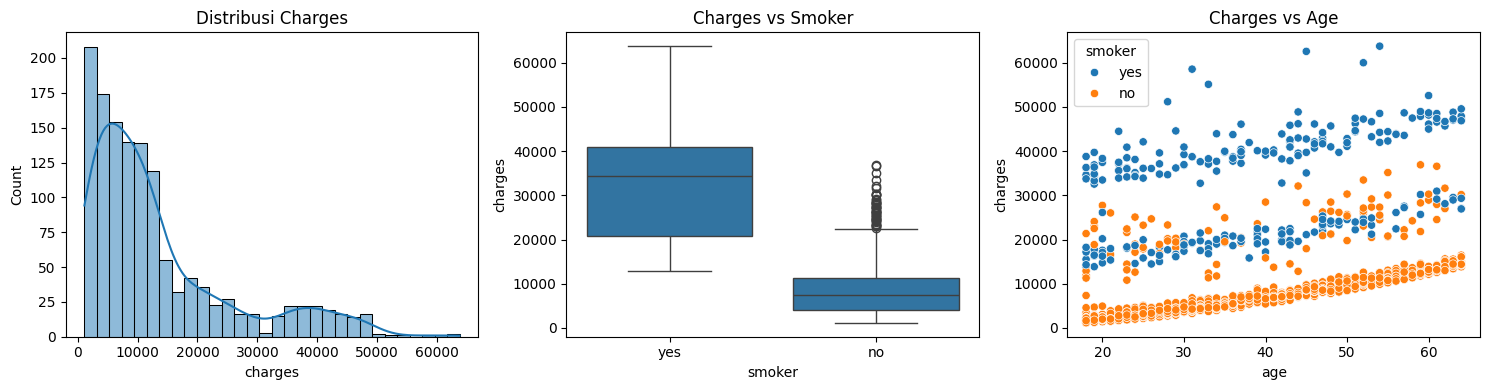

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Charges')

sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1])
axes[1].set_title('Charges vs Smoker')

sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[2])
axes[2].set_title('Charges vs Age')

plt.tight_layout()
plt.show()

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [9]:
X = df.drop('charges', axis=1)
y = df['charges']

In [10]:
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [13]:
lr_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('model', LinearRegression())
])

In [14]:
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [15]:
poly_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

In [16]:
poly_pipe.fit(X_train, y_train)
y_pred_poly = poly_pipe.predict(X_test)


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [17]:
ridge_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('model', Ridge(alpha=1.0))
])

In [18]:
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [19]:
lasso_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])

In [20]:
lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [21]:
dt_pipe = Pipeline([
    ('prep', preprocessor_tree),
    ('model', DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42))
])

In [22]:
dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [23]:
svr_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('model', SVR(kernel='rbf', C=100, epsilon=0.1))
])

In [24]:
svr_pipe.fit(X_train, y_train)
y_pred_svr = svr_pipe.predict(X_test)

# 4. Evaluasi Model

In [25]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = [
    evaluate(y_test, y_pred_lr, 'Linear Regression'),
    evaluate(y_test, y_pred_poly, 'Polynomial Regression'),
    evaluate(y_test, y_pred_ridge, 'Ridge Regression'),
    evaluate(y_test, y_pred_lasso, 'Lasso Regression'),
    evaluate(y_test, y_pred_dt, 'Decision Tree'),
    evaluate(y_test, y_pred_svr, 'SVR')
]

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,MAE,MSE,RMSE,R2
4,Decision Tree,2666.823965,2.033288e+07,4509.199902,0.869030
1,Polynomial Regression,2729.500134,2.071281e+07,4551.132385,0.866583
0,Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
3,Lasso Regression,4182.219786,3.360573e+07,5797.044759,0.783536
2,Ridge Regression,4193.195353,3.364539e+07,5800.464938,0.783281
5,SVR,6314.106969,1.467171e+08,12112.682709,0.054955


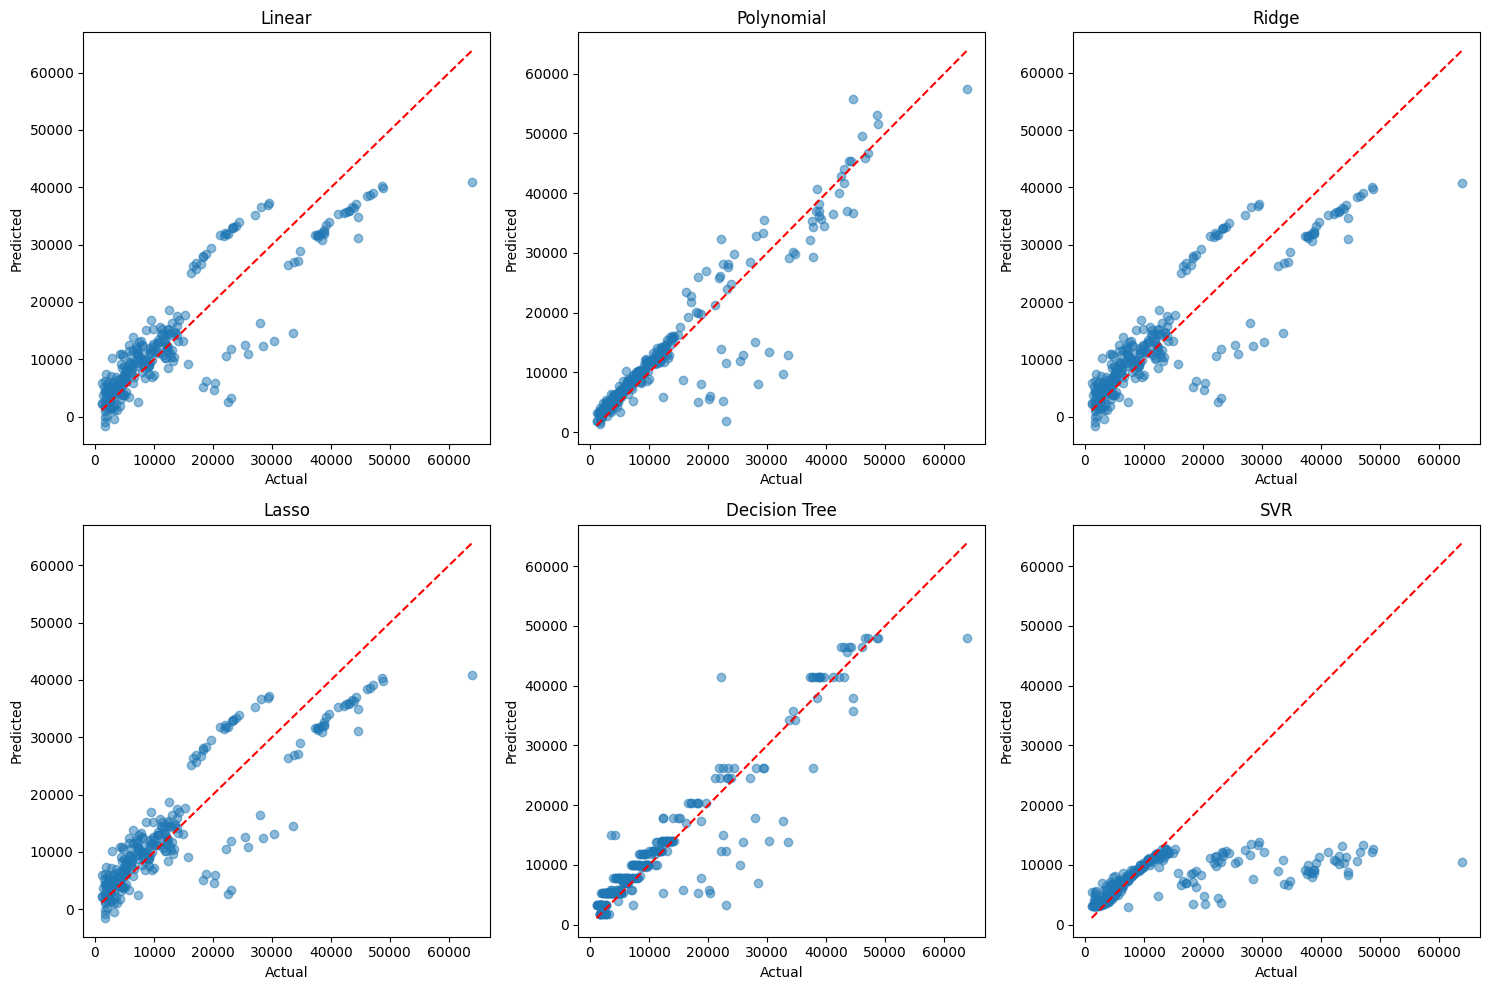

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
preds = [y_pred_lr, y_pred_poly, y_pred_ridge, y_pred_lasso, y_pred_dt, y_pred_svr]
names = ['Linear', 'Polynomial', 'Ridge', 'Lasso', 'Decision Tree', 'SVR']

for ax, pred, name in zip(axes.flatten(), preds, names):
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# 5. Analisis

Berdasarkan tabel evaluasi, Decision Tree dan Polynomial Regression memberikan performa terbaik dengan R2 sekitar 0.87. Keduanya mampu menangkap pola non linear pada data, terutama interaksi antara status merokok, usia, dan BMI terhadap charges. Hal ini terlihat dari scatter plot Polynomial Regression yang titik titiknya lebih rapat mengikuti garis diagonal dibanding Linear Regression.

Linear Regression, Ridge, dan Lasso memiliki performa yang hampir sama dengan R2 sekitar 0.78. Ridge dan Lasso tidak memberikan peningkatan berarti dibanding Linear Regression biasa. Ini menunjukkan bahwa multikolinearitas antar fitur tidak terlalu parah setelah OneHotEncoding, sehingga penalti regularisasi tidak banyak membantu. Nilai alpha yang digunakan juga mungkin belum optimal.

SVR memiliki performa paling buruk dengan R2 hanya 0.05. Scatter plot SVR menunjukkan pola horizontal, artinya prediksi model hampir konstan di sekitar nilai tertentu. Ini terjadi karena parameter C, epsilon, dan gamma belum di tuning dengan baik. SVR sangat sensitif terhadap skala data dan pemilihan parameter, sehingga meskipun data sudah di scaling, konfigurasi default atau nilai yang dipilih belum cocok untuk dataset ini.

Decision Tree dengan max_depth 5 dan min_samples_leaf 5 berhasil mengontrol overfitting dengan baik. Scatter plotnya menunjukkan pola tangga yang khas, yaitu prediksi terbagi ke dalam beberapa nilai diskrit. Meskipun terlihat kurang halus dibanding Polynomial, secara metrik Decision Tree sedikit lebih unggul.

# 6. Kesimpulan dan Saran

## Kesimpulan

- Decision Tree dan Polynomial Regression adalah dua model terbaik pada eksperimen ini dengan R2 sekitar 0.87 dan RMSE sekitar 4500.

- Linear Regression, Ridge, dan Lasso memberikan hasil yang mirip dengan R2 sekitar 0.78. Regularisasi tidak memberikan perbaikan signifikan pada dataset ini.

- SVR tanpa tuning parameter yang tepat memberikan hasil sangat buruk dengan R2 hanya 0.05.

- Preprocessing berupa scaling dan OneHotEncoding sudah sesuai untuk model linear dan SVR, sedangkan Decision Tree tidak memerlukan scaling.

- Fitur smoker, age, dan bmi adalah prediktor utama yang mempengaruhi besarnya charges.

## Saran

Lakukan hyperparameter tuning pada Decision Tree dengan mencoba variasi max_depth, min_samples_split, dan min_samples_leaf untuk melihat apakah performa bisa melampaui 0.87 atau justru mengalami overfitting.